# **Combining DataFrames in Pandas**

## **Why Combine DataFrames?**

In real data projects, information rarely lives in a single file.

You might have:

- Monthly CSV exports
- Transaction data from a database
- Metadata stored in Excel
- Logs generated by an application

<br>

Pandas provides two primary tools for combining data:

| Method        | When to Use                                 |
| ------------- | ------------------------------------------- |
| `pd.concat()` | When DataFrames already align structurally  |
| `pd.merge()`  | When DataFrames must be matched using a key |

<br>


## **Part 1: Concatenation (pd.concat)**


**Concatenation = stacking or gluing DataFrames together**

No matching logic is applied—Pandas simply lines things up by index or column names.

<br>



#### **Quarterly Sales Data (Same Columns)**

In [ ]:
import pandas as pd

q1_sales = pd.DataFrame({
    'store': ['A', 'B', 'C'],
    'revenue': [12000, 15000, 9000]
})

q2_sales = pd.DataFrame({
    'store': ['A', 'B', 'C'],
    'revenue': [14000, 16000, 11000]
})

In [ ]:
q1_sales

,store,revenue
0,A,12000
1,B,15000
2,C,9000


In [ ]:
q2_sales

,store,revenue
0,A,14000
1,B,16000
2,C,11000


### **Concatenation Along Rows (axis=0) (vertical stacking)**

**Use when DataFrames have the same columns and represent different observations.**

In [ ]:
concatenated_df = pd.concat([q1_sales, q2_sales], axis=0)
concatenated_df

,store,revenue
0,A,12000
1,B,15000
2,C,9000
0,A,14000
1,B,16000
2,C,11000


**Key Points**

- Rows are stacked vertically
- Column names must match
- Index is preserved (duplicates allowed)

<br>
When concatenating DataFrames without `ignore_index=True`, Pandas keeps the original index values. If the DataFrames being concatenated have overlapping index values, the resulting DataFrame will have duplicate indices. While this is valid, it can lead to ambiguity when selecting data using `loc`.

<br>



 **Selection with Duplicate Indices**

When you select a row with a duplicate index using `.loc`, Pandas will return *all* rows that share that index value. This is why duplicate indices are allowed—they simply mean that multiple rows share the same index label.

In [ ]:
# Selecting rows with index 0
print("Selecting rows with index 0:")
print(concatenated_df.loc[0])

# Selecting rows with index 1
print("\nSelecting rows with index 1:")
print(concatenated_df.loc[1])

Selecting rows with index 0:
  store  revenue
0     A    12000
0     A    14000

Selecting rows with index 1:
  store  revenue
1     B    15000
1     B    16000



To avoid duplicate indices and get a continuous, unique index, you should reset the index:

use `ignore_index=True` when concatenating, as shown in the next cell.

In [ ]:
pd.concat([q1_sales, q2_sales], ignore_index=True)

,store,revenue
0,A,12000
1,B,15000
2,C,9000
3,A,14000
4,B,16000
5,C,11000


<br>

###**Concatenation Along Columns (axis=1)**

**Different Features, Same Entities**

In [ ]:
store_locations = pd.DataFrame({
    'city': ['NY', 'LA', 'Chicago']
})

store_sizes = pd.DataFrame({
    'size_sqft': [2000, 3500, 1800]
})

In [ ]:
store_locations

,city
0,NY
1,LA
2,Chicago


In [ ]:
store_sizes

,size_sqft
0,2000
1,3500
2,1800


In [ ]:
pd.concat([store_locations, store_sizes], axis=1)

,city,size_sqft
0,NY,2000
1,LA,3500
2,Chicago,1800


**Key Requirement**

- Indexes must align
- Pandas matches rows by index, not by values

<br>

#### **Common Pitfall: Mismatched Columns**

In [ ]:
pd.concat([q1_sales, store_locations], axis=0)

,store,revenue,city
0,A,12000.0,NaN
1,B,15000.0,NaN
2,C,9000.0,NaN
0,NaN,NaN,NY
1,NaN,NaN,LA
2,NaN,NaN,Chicago


This produces NaN values because Pandas preserves column integrity.

#### **Why concat is wrong here**

pd.concat assumes structural compatibility, meaning:

- Same columns → stack rows
- Same index → add columns

But in our example:
```
q1_sales
# store | revenue

store_locations
# city
```

There is no semantic alignment.

<br>


#### **What you actually want conceptually**

“For each store, attach its city.”

That is relational logic:

- One table describes sales
- Another table describes store metadata
- They should be connected by a key

That is exactly what merge / join is for.

<br>

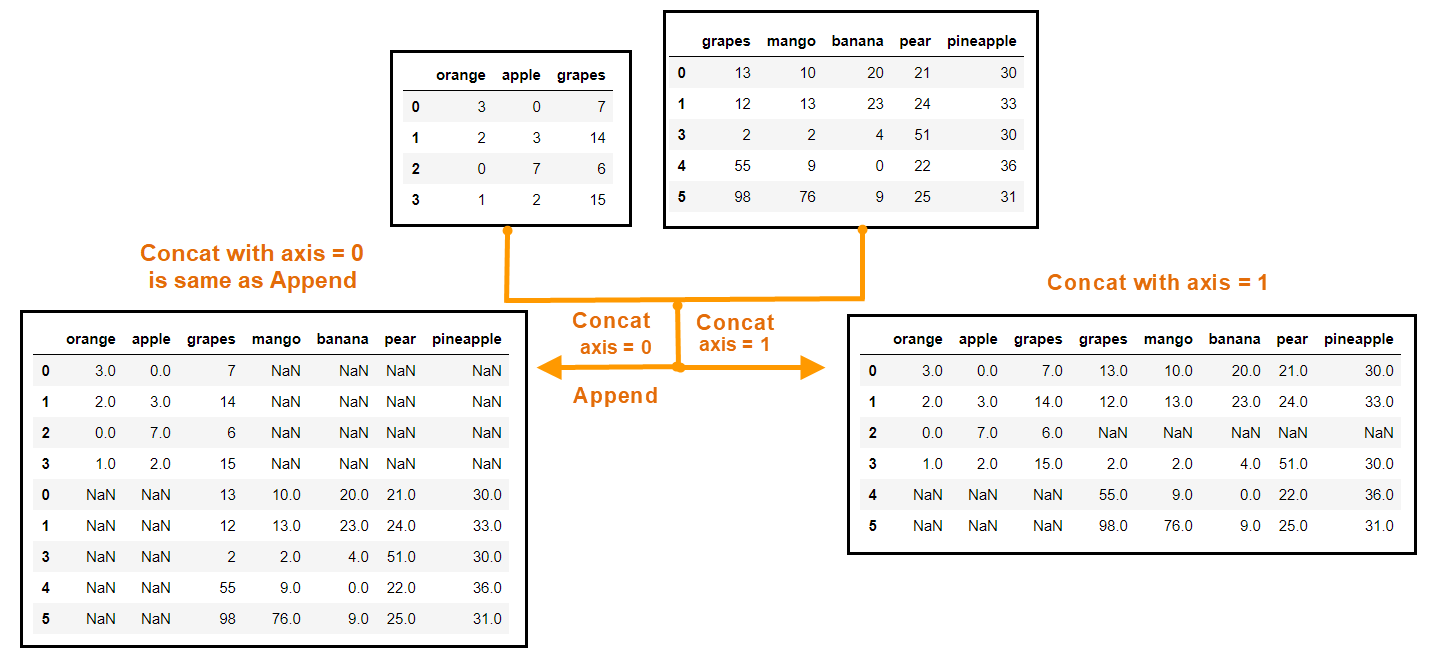

<br>


## **Part 2: Merging DataFrames (pd.merge)**


**Merge = SQL-style join using a key**

You must decide:

1. **On** what column to merge together? or What column identifies the same entity?

    - The **on** column should be a *primary* identifier (unique per row)
    - The **on** column should be present in both tables being merged

2. How to merge the tables on the chosen column? or What to do with rows that don’t match?

<br>

#### **Example Scenario: Online Store**

**Customers Table**

In [ ]:
customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Carol', 'Dan']
})
customers

,customer_id,name
0,1,Alice
1,2,Bob
2,3,Carol
3,4,Dan


**Orders Table**

In [ ]:
orders = pd.DataFrame({
    'order_id': [101, 102, 103],
    'customer_id': [1, 2, 5],
    'amount': [250, 180, 300]
})
orders

,order_id,customer_id,amount
0,101,1,250
1,102,2,180
2,103,5,300


**Choosing a Merge Key**

✔️ A good merge key:

- Exists in both tables
- Identifies the same entity
- Is preferably unique

Here: `customer_id`

### **Inner Join (Intersection)**

The result will be the set of rows that match in both tables.

In [ ]:
pd.merge(customers, orders, how='inner', on='customer_id')

,customer_id,name,order_id,amount
0,1,Alice,101,250
1,2,Bob,102,180


**Interpretation**

- Keeps only customers who placed orders
- Drops unmatched rows from both tables

📌 Think: “only what exists in both”

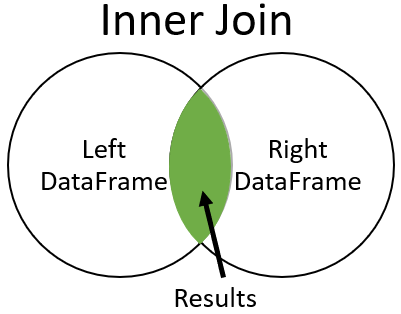

### **Left Join (Preserve Left Table)**

**Note:** The order of the tables being passed as argument does matter here!

In [ ]:
pd.merge(customers, orders, how='left', on='customer_id')

,customer_id,name,order_id,amount
0,1,Alice,101.0,250.0
1,2,Bob,102.0,180.0
2,3,Carol,NaN,NaN
3,4,Dan,NaN,NaN


**Interpretation**

- Keeps all customers
- Missing orders become NaN

📌 Think: “all customers, even if they didn’t order”

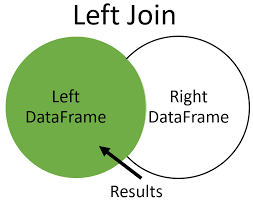

### **Right Join (Preserve Right Table)**

**Note:** The order of the tables being passed as argument does matter here!

In [ ]:
pd.merge(customers, orders, how='right', on='customer_id')

,customer_id,name,order_id,amount
0,1,Alice,101,250
1,2,Bob,102,180
2,5,NaN,103,300


**Interpretation**

- Keeps all orders
- Customers not found become NaN

📌 Less common, but useful for audit-style checks

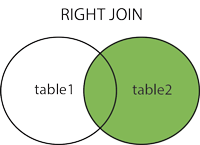

### **Outer Join (Union)**

In [ ]:
pd.merge(customers, orders, how='outer', on='customer_id')

,customer_id,name,order_id,amount
0,1,Alice,101.0,250.0
1,2,Bob,102.0,180.0
2,3,Carol,NaN,NaN
3,4,Dan,NaN,NaN
4,5,NaN,103.0,300.0


**Interpretation**

- Keeps everything from both tables
- Missing values filled with NaN

📌 Think: “give me everything”

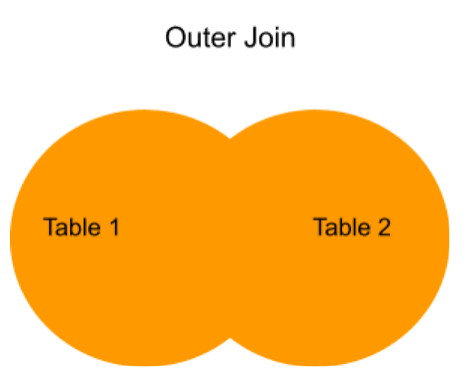

<br><br>

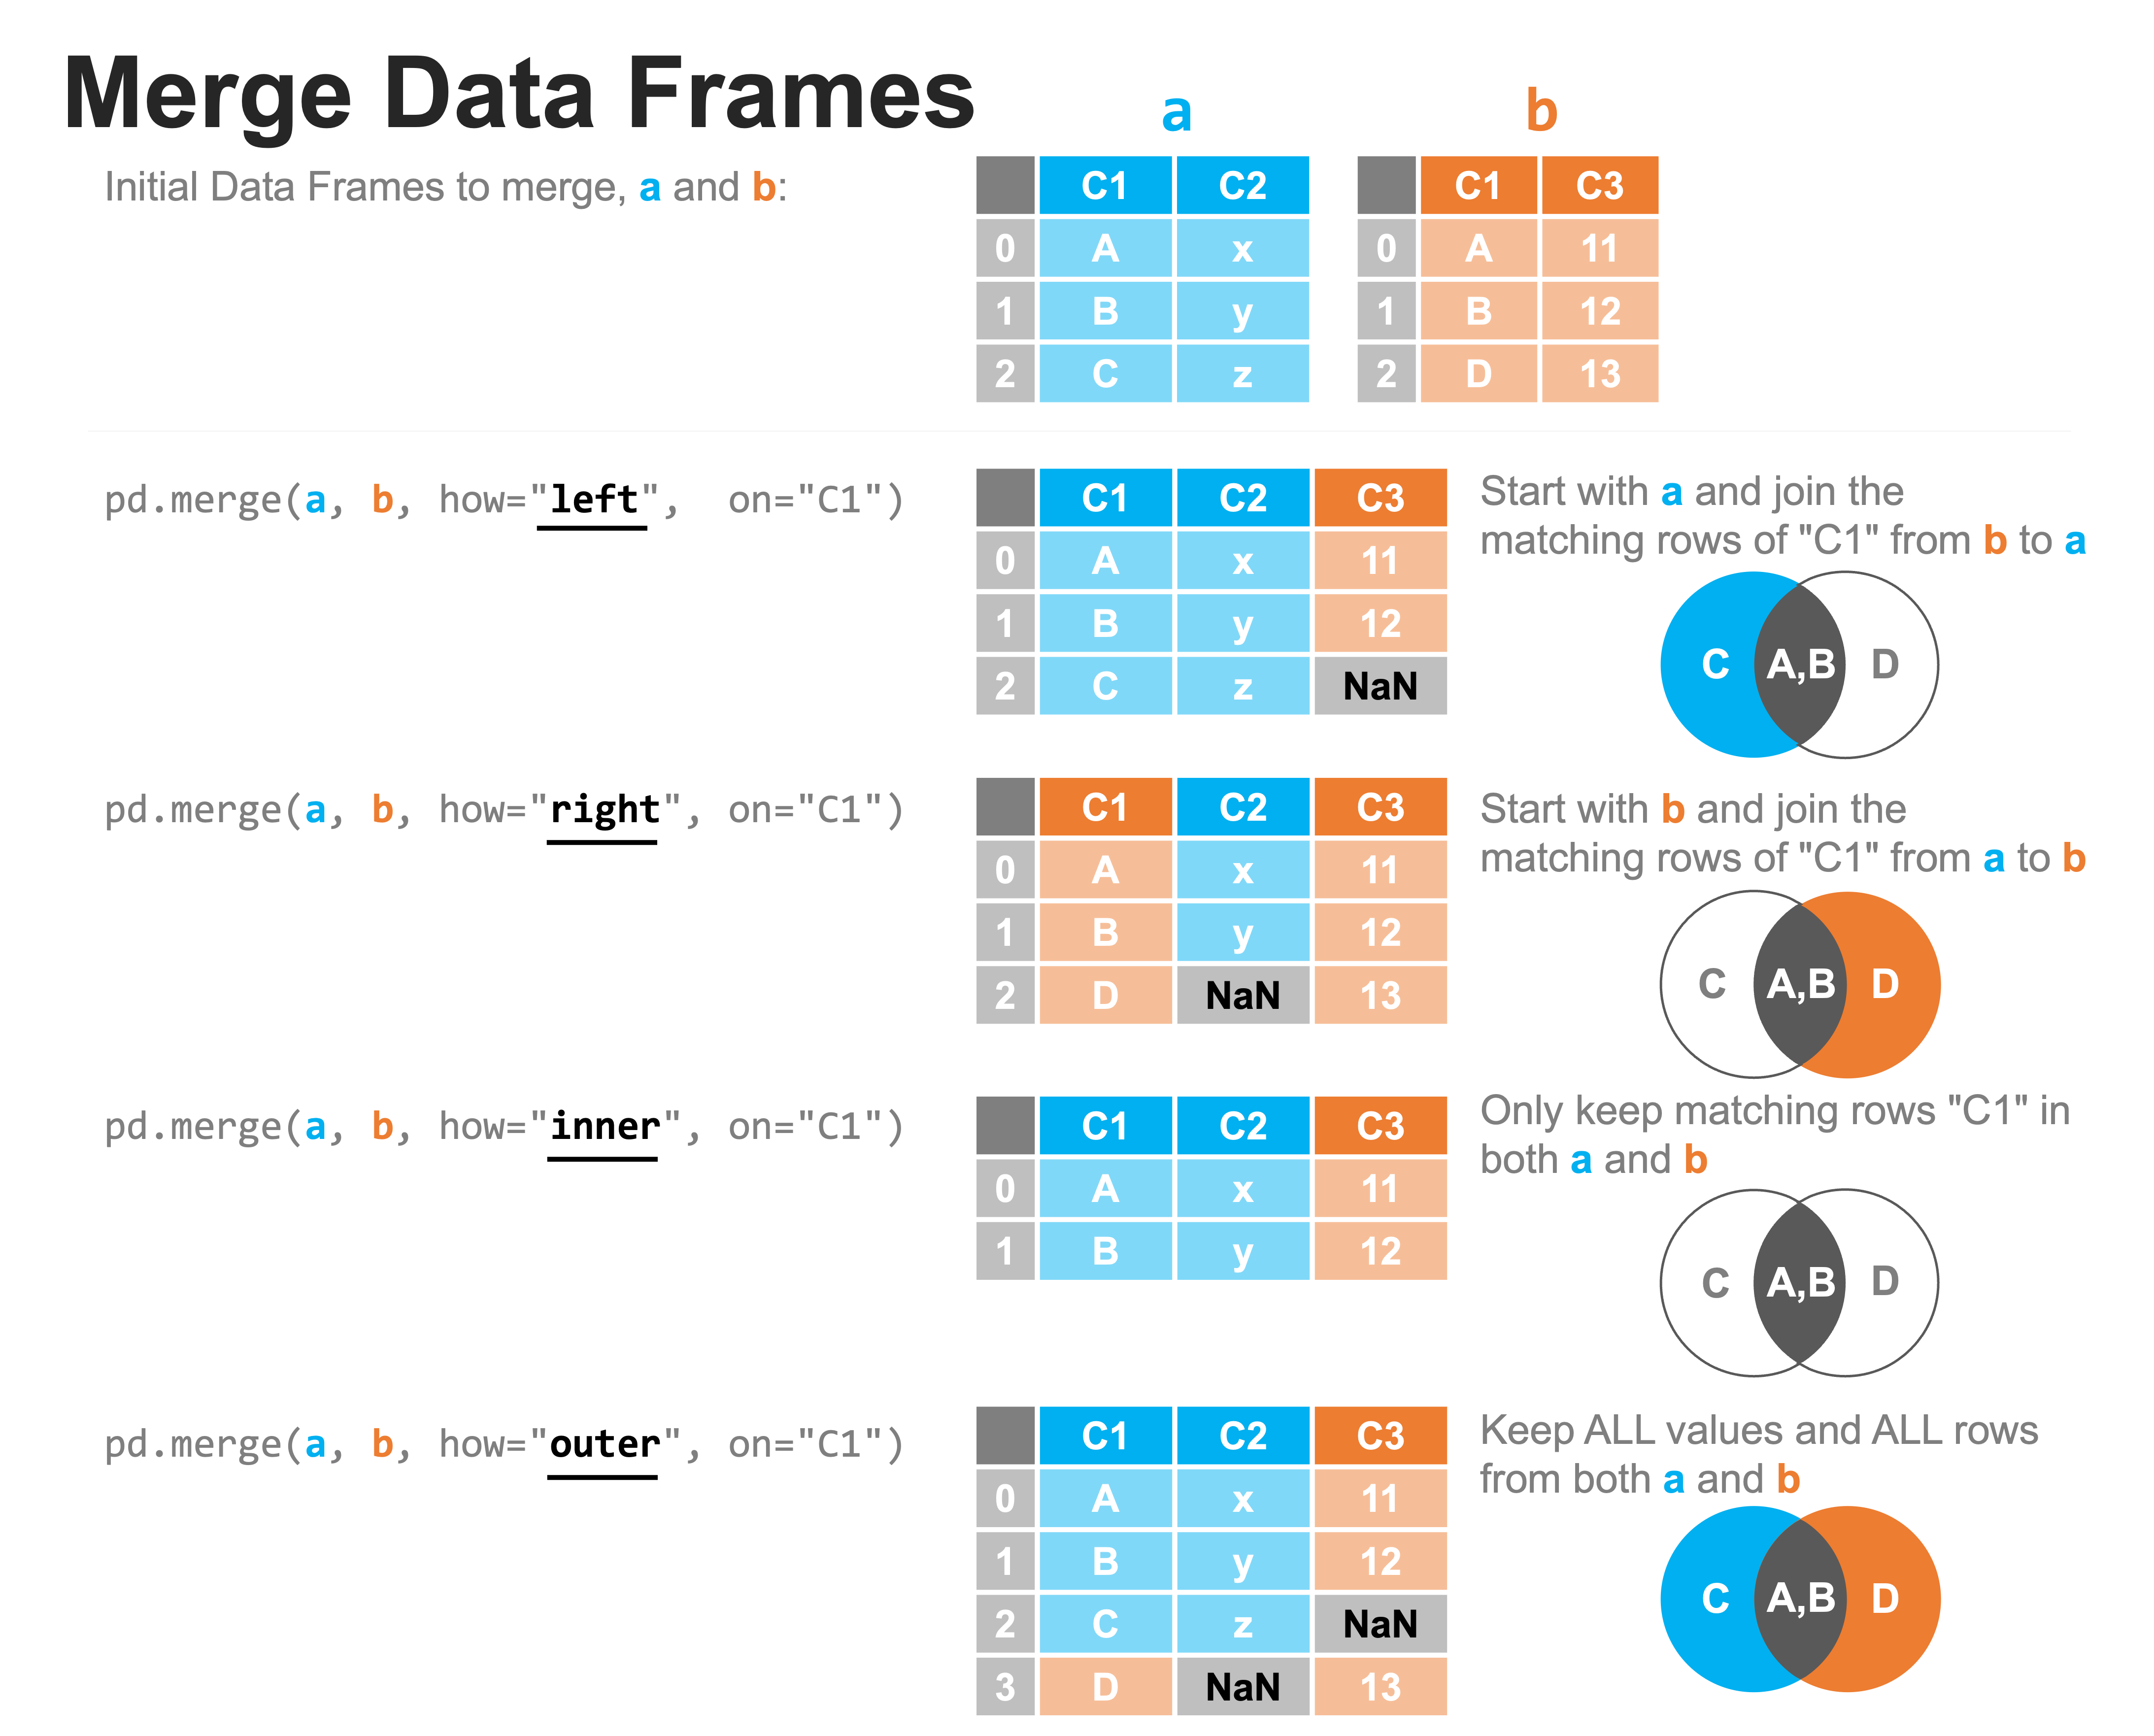

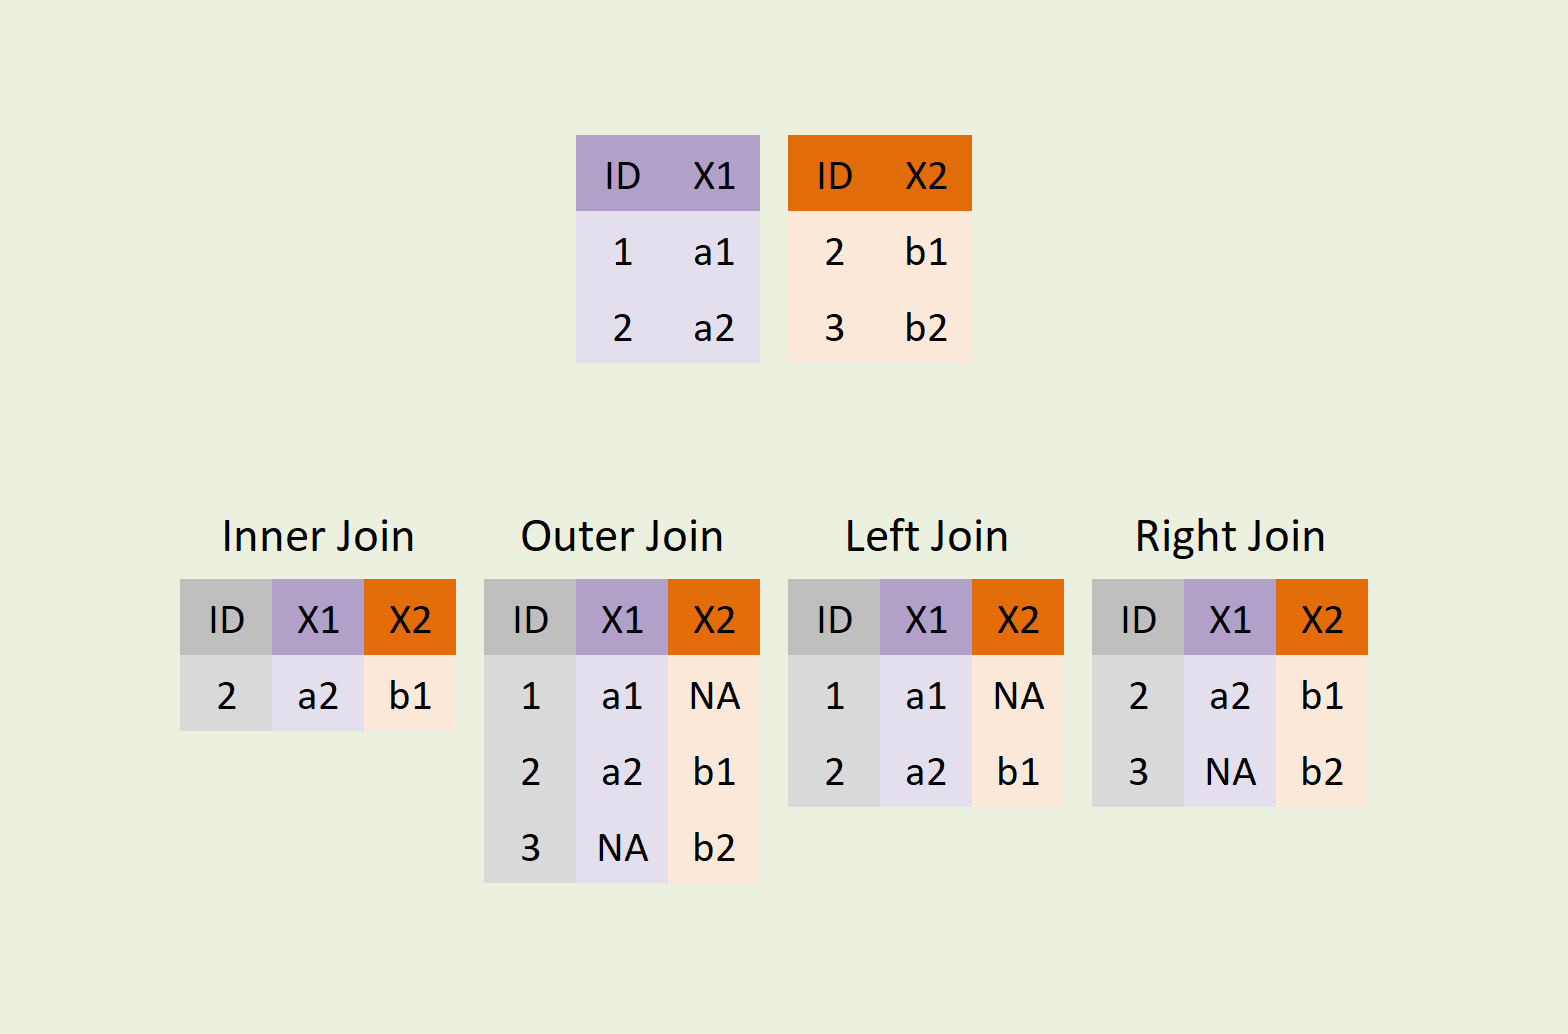

<br>

## **Joining on Index Instead of Columns**





Merging two tables by matching the index of one DataFrame with a column in another.

We use the index of `customers` as the join key instead of keeping it as a regular column.

In [ ]:
customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Carol', 'Dan']
})
customers

,customer_id,name
0,1,Alice
1,2,Bob
2,3,Carol
3,4,Dan


In [ ]:
orders = pd.DataFrame({
    'order_id': [101, 102, 103],
    'customer_id': [1, 2, 5],
    'amount': [250, 180, 300]
})
orders

,order_id,customer_id,amount
0,101,1,250
1,102,2,180
2,103,5,300


In [ ]:
customers = customers.set_index('customer_id')
customers

,name
customer_id,
1,Alice
2,Bob
3,Carol
4,Dan


Move the unique identifier into the index to represent each customer more naturally.

In [ ]:
pd.merge(customers, orders, left_index=True, right_on='customer_id')

,name,order_id,customer_id,amount
0,Alice,101,1,250
1,Bob,102,2,180


Match each order to the correct customer by joining the orders’ **customer_id** column to the customers’ index.

When you use `pd.merge(customers, orders, left_index=True, right_on='customer_id')`:

*   **`left_index=True`**: This tells Pandas to use the index of the *left* DataFrame (`customers`) as one of the keys for merging. Since we previously set `customer_id` as the index of `customers` (using `customers.set_index('customer_id')`), the merge operation will use these index values.

*   **`right_on='customer_id'`**: This tells Pandas to use the column named 'customer_id' from the *right* DataFrame (`orders`) as the other key for merging.

In essence, this merge operation matches rows where the `customer_id` from the `orders` DataFrame's column is equal to the index of the `customers` DataFrame.

**When This Is Useful**

- IDs already stored as index
- Cleaner table structure
- Avoids redundant columns

### **Different Key Names**

Joining two tables where the same identifier has different column names.

In [ ]:
shipments = pd.DataFrame({
    'cust_id': [1, 3],
    'carrier': ['UPS', 'FedEx']
})
shipments

,cust_id,carrier
0,1,UPS
1,3,FedEx


Explicitly tell pandas which columns represent the same key, even though their names differ.

In [ ]:
pd.merge(customers.reset_index(),
         shipments,
         left_on='customer_id',
         right_on='cust_id')

,customer_id,name,cust_id,carrier
0,1,Alice,1,UPS
1,3,Carol,3,FedEx


Why reset_index()?

Because merge works on columns, and customer_id is currently stored in the index.

After the merge

The same identifier may appear twice (customer_id and cust_id), so we often drop one to avoid redundancy.
